# Car License Plate Detection with YOLO11n

Train and evaluate a YOLO11n object detector on the Car License Plate Detection dataset (433 images, YOLO-format labels, 1 class).

- **Train:** 346 images
- **Test:** 87 images
- **Label format:** `class xc yc w h` (normalized)

**Tip:** run this on a GPU runtime (Kaggle: *Accelerator > GPU*, Colab: *Runtime > Change runtime type*).

## 1. Install & imports

In [ ]:
!pip install -q ultralytics easyocr

In [1]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from ultralytics import YOLO

print("Setup complete")

Setup complete


## 2. Load your existing `data.yaml`

The dataset lives on a network share. To keep training fast (thousands of small file reads over the network are slow), the dataset is **copied once to a local folder**, and a local yaml is generated from your original one. Your original `data.yaml` is not modified.

In [2]:
import shutil

# Your existing yaml on the network share
SRC_YAML = Path(r"\\192.168.1.10\shear all\day7\License-Plate-Data\data.yaml")
SRC_DIR = SRC_YAML.parent

# Local working copy
DATASET_DIR = Path("License-Plate-Data").resolve()

with open(SRC_YAML) as f:
    src_cfg = yaml.safe_load(f)
print("Original yaml:", src_cfg)

if not DATASET_DIR.exists():
    print("Copying dataset from the network share...")
    shutil.copytree(SRC_DIR, DATASET_DIR, ignore=shutil.ignore_patterns("*.cache"))
print("Local dataset:", DATASET_DIR)

for split in ("train", "test"):
    imgs = sorted((DATASET_DIR / split / "images").glob("*.png"))
    lbls = sorted((DATASET_DIR / split / "labels").glob("*.txt"))
    print(f"{split}: {len(imgs)} images, {len(lbls)} labels")

Original yaml: {'names': {0: 'license_plate'}, 'nc': 1, 'train': '//192.168.1.10/shear all/day7/License-Plate-Data/train', 'val': '//192.168.1.10/shear all/day7/License-Plate-Data/test'}
Copying dataset from the network share...
Local dataset: C:\Users\PC-LAB1\Downloads\License-Plate-Data
train: 346 images, 346 labels
test: 87 images, 87 labels


## 3. Validate annotations

In [3]:
def check_labels(split):
    bad = 0
    for lbl in (DATASET_DIR / split / "labels").glob("*.txt"):
        img = DATASET_DIR / split / "images" / f"{lbl.stem}.png"
        if not img.exists():
            print("Missing image for", lbl.name); bad += 1
        for line in lbl.read_text().strip().splitlines():
            p = line.split()
            if len(p) != 5 or not all(0 <= float(v) <= 1 for v in p[1:]):
                print("Bad line in", lbl.name, ":", line); bad += 1
    print(f"{split}: {bad} problems found")

check_labels("train")
check_labels("test")

train: 0 problems found
test: 0 problems found


## 4. Create the local `data.yaml`

Class names come from your original yaml; the paths point to the local copy. Your yaml only defines `train` and `val` (both folders come from your split), so `test` is set to the same test folder as `val`.

In [4]:
data_cfg = {
    "path": str(DATASET_DIR),
    "train": "train/images",
    "val": "test/images",
    "test": "test/images",
    "nc": src_cfg["nc"],
    "names": src_cfg["names"],
}

DATA_YAML = Path("data_local.yaml").resolve()
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print(DATA_YAML.read_text())

path: C:\Users\PC-LAB1\Downloads\License-Plate-Data
train: train/images
val: test/images
test: test/images
nc: 1
names:
  0: license_plate



## 5. Visualize sample images with ground-truth boxes

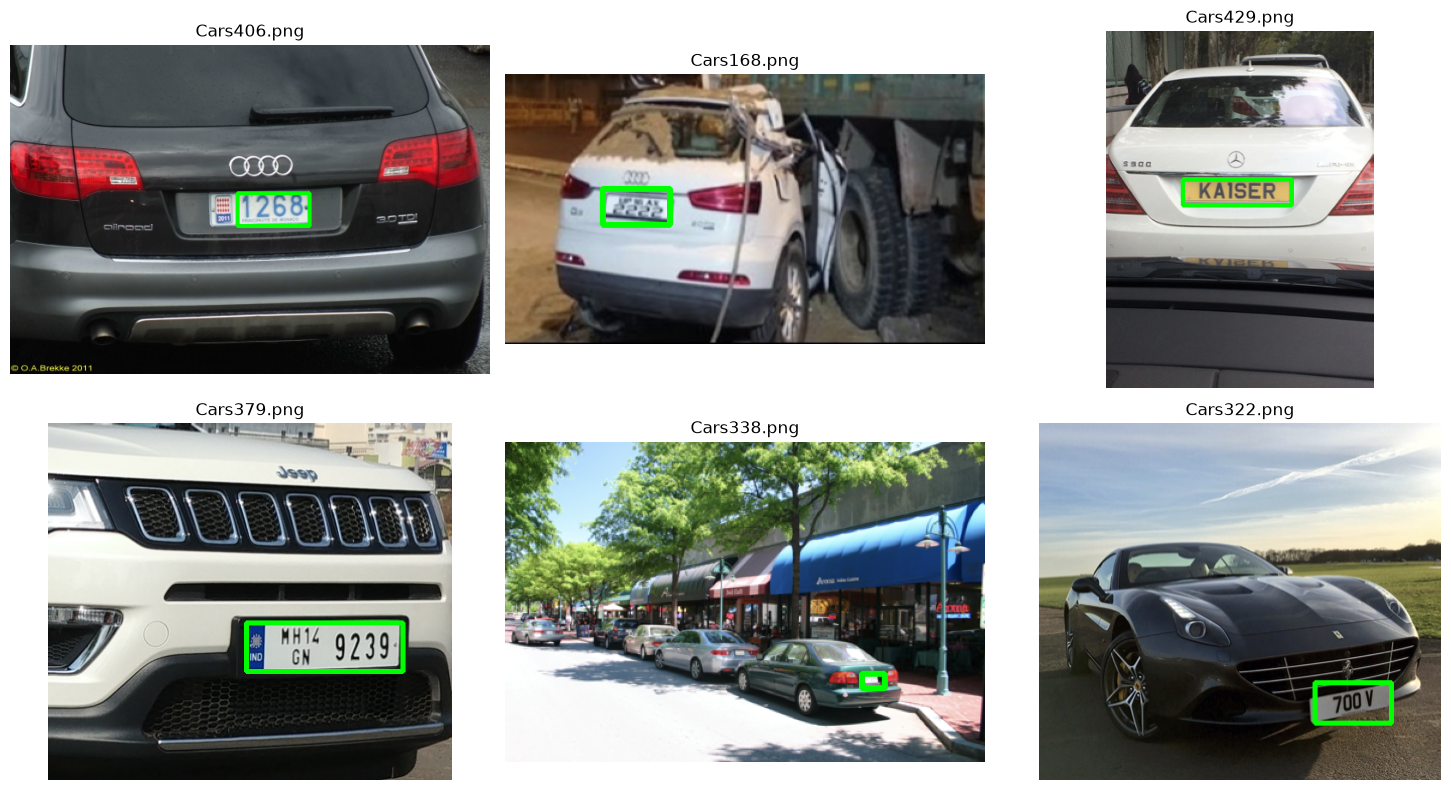

In [5]:
def draw_gt(img_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
    for line in lbl.read_text().strip().splitlines():
        _, xc, yc, bw, bh = map(float, line.split())
        x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
        x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    return img

samples = random.sample(sorted((DATASET_DIR / "train/images").glob("*.png")), 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, p in zip(axes.ravel(), samples):
    ax.imshow(draw_gt(p)); ax.set_title(p.name); ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Train YOLO11n

In [7]:
model = YOLO("yolo11n.pt")   # pretrained COCO weights, downloaded automatically

results = model.train(
    data=str(DATA_YAML),
    epochs=20,
    imgsz=640,
    batch=16,
    patience=15,        # early stopping
    fliplr=0.0,         # don't mirror plates (text would be reversed)
    project="runs",
    name="plate_yolo11n",
    exist_ok=True,
)

Ultralytics 8.4.165  Python-3.12.0 torch-2.14.0+cpu CPU (12th Gen Intel Core i7-12700)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\PC-LAB1\Downloads\data_local.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_yolo11n, nbs=64, nms=None, opset=None, 

## 7. Training curves

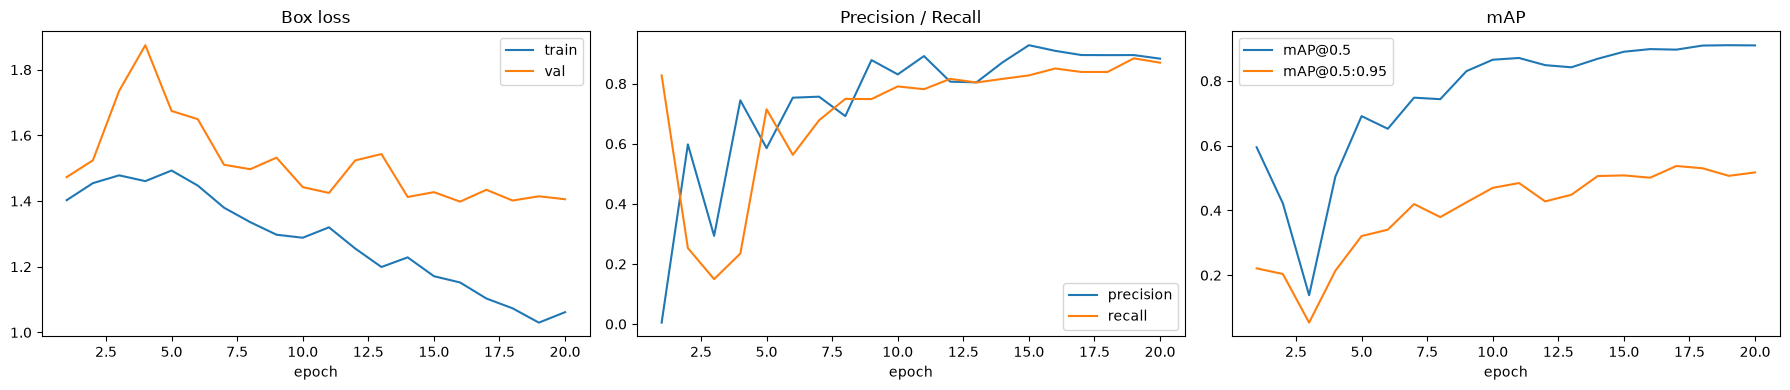

In [19]:
RUN_DIR = Path(r"C:\Users\PC-LAB1\Desktop\mu\runs\detect\runs\plate_yolo11n")
df = pd.read_csv(RUN_DIR / "results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(df["epoch"], df["train/box_loss"], label="train"); axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
axes[0].set_title("Box loss"); axes[0].legend()
axes[1].plot(df["epoch"], df["metrics/precision(B)"], label="precision"); axes[1].plot(df["epoch"], df["metrics/recall(B)"], label="recall")
axes[1].set_title("Precision / Recall"); axes[1].legend()
axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5"); axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
axes[2].set_title("mAP"); axes[2].legend()
for a in axes: a.set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 8. Evaluate on the test set

In [18]:
RUN_DIR = Path(r"C:\Users\PC-LAB1\Desktop\mu\runs\detect\runs\plate_yolo11n")

best = YOLO(RUN_DIR / "weights" / "best.pt")

m = best.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640
)

print(f"Precision     : {m.box.mp:.3f}")
print(f"Recall        : {m.box.mr:.3f}")
print(f"mAP@0.5       : {m.box.map50:.3f}")
print(f"mAP@0.5:0.95  : {m.box.map:.3f}")

Ultralytics 8.4.165  Python-3.12.0 torch-2.14.0+cpu CPU (12th Gen Intel Core i7-12700)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 447.5170.4 MB/s, size: 439.6 KB)
val: Scanning C:\Users\PC-LAB1\Downloads\License-Plate-Data\test\labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.3s0.9ss
                   all         87         87      0.868      0.828      0.891      0.532
Speed: 1.5ms preprocess, 32.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\PC-LAB1\Desktop\mu\runs\detect\val
Precision     : 0.868
Recall        : 0.828
mAP@0.5       : 0.891
mAP@0.5:0.95  : 0.532


## 9. Predict on test images

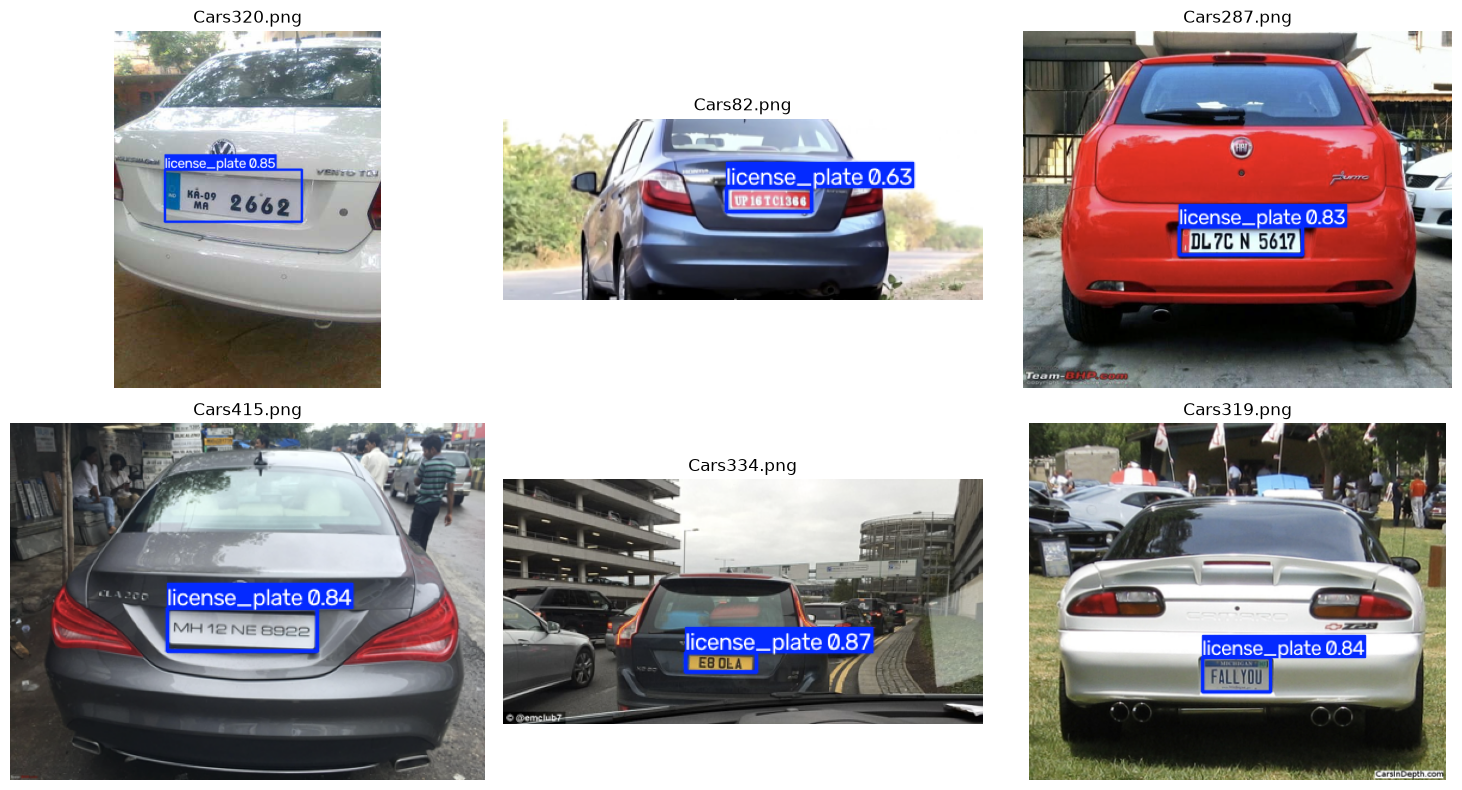

In [20]:
test_imgs = random.sample(sorted((DATASET_DIR / "test/images").glob("*.png")), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, p in zip(axes.ravel(), test_imgs):
    r = best.predict(str(p), conf=0.25, verbose=False)[0]
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(p.name); ax.axis("off")
plt.tight_layout(); plt.show()

## 10. (Optional) Read the plate text with OCR

Using CPU. Note: This module is much faster with a GPU.


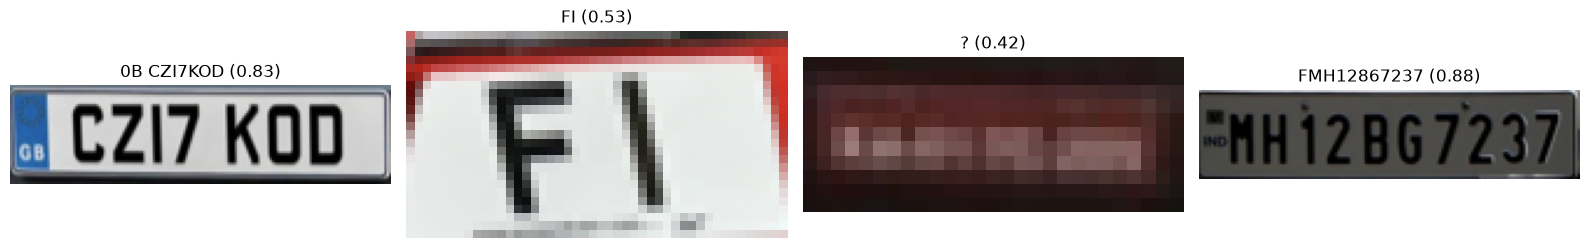

In [27]:
import easyocr
reader = easyocr.Reader(["en"], gpu=False)

def read_plates(image_path, conf=0.25):
    img = cv2.imread(str(image_path))
    r = best.predict(img, conf=conf, verbose=False)[0]
    out = []
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        crop = img[y1:y2, x1:x2]
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        text = " ".join(t[1] for t in reader.readtext(
            gray, allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-")).strip()
        out.append((text, float(box.conf[0]), crop))
    return out

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
shown = 0
for p in sorted((DATASET_DIR / "test/images").glob("*.png")):
    for text, c, crop in read_plates(p):
        if shown < 4:
            axes[shown].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            axes[shown].set_title(f"{text or '?'} ({c:.2f})"); axes[shown].axis("off")
            shown += 1
    if shown >= 4: break
plt.tight_layout(); plt.show()

## 11. Test on your own image


image 1/1 C:\Users\PC-LAB1\Desktop\day7\License-Plate-Data\train\images\Cars55.png: 480x640 1 license_plate, 61.9ms
Speed: 2.4ms preprocess, 61.9ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


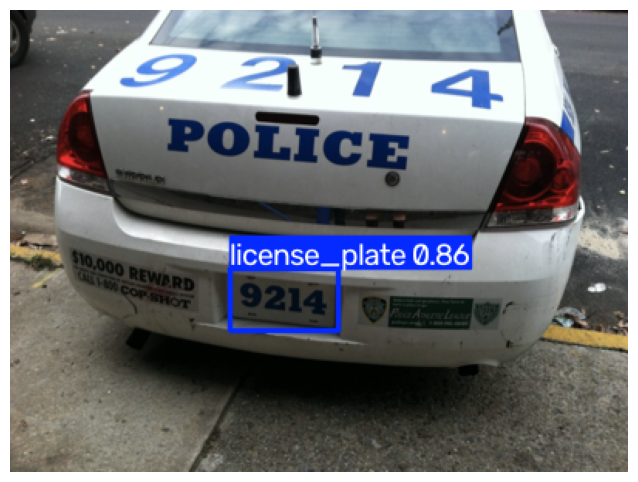

In [28]:
# Replace with the path to any car image
my_image = r"C:\Users\PC-LAB1\Desktop\day7\License-Plate-Data\train\images\Cars55.png"

r = best.predict(my_image, conf=0.25)[0]
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

Plate text: 9214  (detection confidence 0.86)


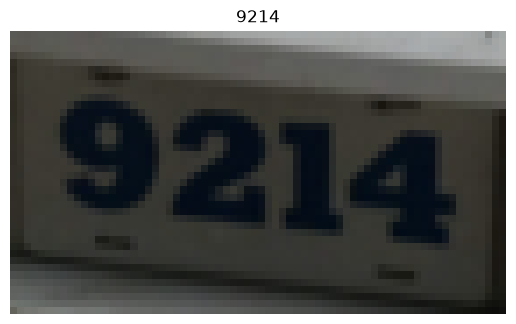

In [ ]:
my_image =  r"C:\Users\PC-LAB1\Desktop\day7\License-Plate-Data\train\images\Cars55.png"   # change this

plates = read_plates(my_image)           # detect plate + read text
if not plates:
    print("No plate detected. Try a lower confidence, e.g. read_plates(my_image, conf=0.1)")
for text, conf, crop in plates:
    print(f"Plate text: {text or '?'}  (detection confidence {conf:.2f})")
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); plt.title(text); plt.axis("off"); plt.show()

In [30]:
import pandas as pd

# مسار نتائج التدريب
RESULTS_CSV = RUN_DIR / "results.csv"

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

# عرض جميع الـ Epochs
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(df)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,76.7304,1.40254,3.23431,1.25930,0.00477,0.82759,0.59509,0.22116,1.47287,3.75979,1.17693,0.000636,0.000636,0.000636
1,2,149.2340,1.45437,2.33799,1.25801,0.59805,0.25287,0.42183,0.20379,1.52378,3.64791,1.23675,0.001239,0.001239,0.001239
2,3,224.8210,1.47823,2.08142,1.24889,0.29363,0.14943,0.13824,0.05361,1.73518,4.13498,1.44936,0.001775,0.001775,0.001775
3,4,320.6830,1.46060,1.93468,1.26603,0.74467,0.23476,0.50434,0.21369,1.87452,3.46984,1.51329,0.001703,0.001703,0.001703
4,5,400.6400,1.49291,1.78225,1.26329,0.58568,0.71494,0.69129,0.32093,1.67431,2.41821,1.42232,0.001604,0.001604,0.001604
5,6,493.2190,1.44700,1.64197,1.25806,0.75343,0.56322,0.65215,0.34061,1.64922,2.40981,1.47782,0.001505,0.001505,0.001505
6,7,567.2920,1.37966,1.49881,1.19791,0.75682,0.67816,0.74824,0.41973,1.51041,1.97859,1.34343,0.001406,0.001406,0.001406
7,8,639.2100,1.33563,1.41384,1.21148,0.69212,0.74936,0.74359,0.37944,1.49691,2.10112,1.36150,0.001307,0.001307,0.001307
8,9,711.7260,1.29744,1.28276,1.17781,0.87862,0.74887,0.83028,0.42512,1.53212,1.75840,1.35305,0.001208,0.001208,0.001208
9,10,783.9070,1.28821,1.22237,1.17144,0.83094,0.79094,0.86538,0.46975,1.44236,1.81620,1.30377,0.001109,0.001109,0.001109
